**${\mathcal P}^1$ comme machine**. 
On rappelle l'idée de la construction:
* $\psi_i(t):=\max(t-t_i,0)$ donne des fonctions de ${\mathcal P}^1_h$ qui s'annullent pour $t\le t_i$. Sa dérivée a une discontinuité en $t_i$.
* $\phi_i$, fonction de base canonique de ${\mathcal P}^1_h$, dont la dérivée possède trois points de disconuité $t_{i-1}, t_i, t_{i+1}$ s'écrit donc comme $$\phi_i = \alpha_i \psi_{i-1} + \beta_i \psi_i + \gamma_i \psi_{i+1}.$$
* on trouve les coefficients $\alpha,\beta,\gamma$ par les trois conditions $$\phi(t_{i-1})=0, \quad\phi(t_{i})=1, \quad\phi(t_{i+1})=0. $$
*Remarque* : on ajoute deux points au maillage pour les fonctions de bases aux extrémités.
*Remarque* : on les appele ici ${\mathcal S}^1$, car c'est aussi l'espace de spline d'ordre un. Le  ${\mathcal S}^k$, spline d'ordre $k$ de class $C^{k-1}$ s'écrivent d'ailleurs de façon similaire.

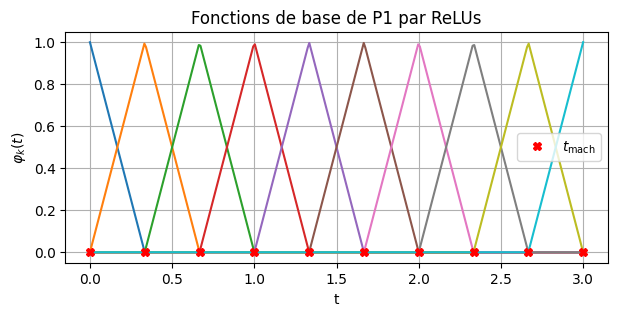

In [3]:
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
import numpy as np


def relu_hat_basis(t_machine, t):
    t_machine = jnp.sort(t_machine)
    n_machine = len(t_machine)

    # Ghost points
    t_left = t_machine[0] - (t_machine[1]-t_machine[0])
    t_right = t_machine[-1] + (t_machine[-1]-t_machine[-2])
    t_full = jnp.concatenate([jnp.array([t_left]), t_machine, jnp.array([t_right])])

    dt = t_full[1:] - t_full[:-1]
    dtinv = 1.0 / dt

    # Make alpha, beta, gamma exactly length n_machine
    alpha = dtinv[1:1+n_machine]   # slice of length 10
    gamma = dtinv[0:n_machine]     # slice of length 10
    beta = -alpha - gamma

    W = jnp.ones(len(t_full))
    b = -t_full

    y = jnp.maximum(0.0, W[:, None] * t[None,:] + b[:, None])

    # Now all slices have length n_machine
    phi = alpha[:, None] * y[2:2+n_machine,:] \
        + beta[:, None] * y[1:1+n_machine,:] \
        + gamma[:, None] * y[0:0+n_machine,:]

    return phi   # shape (n_machine, len(t))    

# Points de collocation
t0, t1, n_colloc = 0.0, 3.0, 10
t_machine = jnp.linspace(t0, t1, n_colloc)
t_plot = jnp.linspace(t0, t1, 300)
phi = np.asarray(relu_hat_basis(t_machine, t_plot))

def plot_bases(t_plot, phi, t_machine, title="Fonctions de base de P1 par ReLUs"):
    plt.figure(figsize=(7,3))
    plt.plot(t_plot, phi.T)
    plt.plot(np.asarray(t_machine), np.zeros_like(np.asarray(t_machine)), 'Xr', label=r'$t_{\rm mach}$')
    plt.title(title)
    plt.xlabel("t")
    plt.ylabel(r"$\varphi_k(t)$")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_bases(t_plot, phi, t_machine)

Maintant, on utilise notre classe S1 pour interpoler une fonction. Notre 'machine' est un réseau de neurones consistant en une dernière couche linéaire, les coefficients $c\in\mathbb R^{n+1}$ dans
$$u_h(t) = \sum_{i=0}^n c_i \phi_i(t).$$
On minimise la perte
$${\mathcal L}(c) = \frac{1}{2n}\sum_{i=0}^n \left(u(t_i)-u_h(t_i)\right)^2.$$
Il s'agit ici de voir comment fonctionne notre 'apprentissage'. On pourrait trouver la solution plus simplement...

Epoch       0, Loss: 4.500e-01
Epoch      10, Loss: 1.160e-02
Epoch      20, Loss: 2.710e-04
Epoch      30, Loss: 8.017e-06
Epoch      40, Loss: 3.001e-07
Epoch      50, Loss: 1.799e-08
Epoch      60, Loss: 4.183e-10
Epoch      70, Loss: 7.420e-12
Epoch      80, Loss: 2.132e-13
Epoch      90, Loss: 8.527e-15


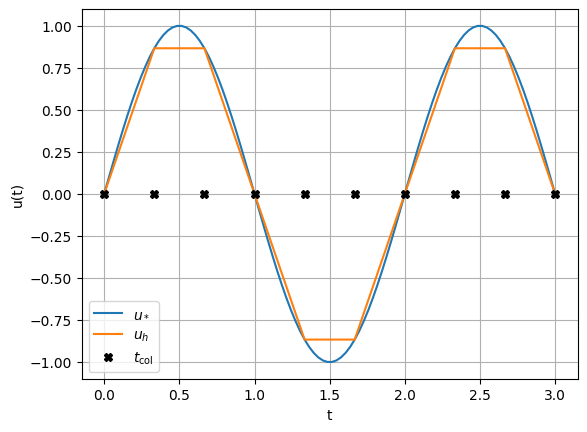

In [4]:
import optax

t0, t1, n_colloc = 0, 3, 10
t_colloc = np.linspace(t0, t1, n_colloc)

def u(t):
    return np.sin(np.pi * t)

data = (t_colloc, u(t_colloc))

def machine(t_machine, coeff, t):
    phi = relu_hat_basis(t_machine, t)  # (n_colloc, len(t))
    return jnp.dot(coeff, phi)

def loss(params):
    res = data[1] - machine(t_colloc, params, data[0])
    return jnp.mean(res ** 2)
 
params = jnp.zeros(shape=(len(t_colloc)))
optimizer = optax.lbfgs(learning_rate=0.1)
opt_state = optimizer.init(params)


@jax.jit
def train_step(params, opt_state):
    loss_value, grads = jax.value_and_grad(loss)(params)
    updates, opt_state = optimizer.update(
        grads, opt_state, params, value=loss_value, grad=grads, value_fn=loss
    )
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss_value, grads, updates

n_epochs = 100
for epoch in range(n_epochs):
    params, opt_state, loss_value, grads, updates = train_step(params, opt_state)
    if epoch % 10== 0:
        print(f"Epoch {epoch:7d}, Loss: {loss_value:.3e}")

def plot_results(t_plot, uplot, uhplot, pointlist=[]):
    plt.plot(t_plot, uplot, label=r'$u_*$')
    plt.plot(t_plot, uhplot, label=r'$u_h$')
    for i,pointl in enumerate(pointlist):
        t_colloc, style, label = pointl
        plt.plot(t_colloc, np.zeros_like(t_colloc)+i*0.1, style, label=label)
    plt.legend()
    plt.xlabel("t")
    plt.ylabel("u(t)")
    plt.grid(True)
    plt.show()
t_plot = np.linspace(t0, t1, 100)
plot_results(t_plot, u(t_plot), machine(t_colloc, params, t_plot), [(t_colloc, 'Xk', r'$t_{\rm col}$')])


Comme on va utiliser toujours le même type de boucle d'apprentissage, on met cela dans une fonction, que l'on pourra utiliser plus tard. On teste avec l'exemple précédent.

Epoch       0, Loss: 4.500e-01
Epoch      10, Loss: 1.160e-02
Epoch      20, Loss: 2.710e-04
Epoch      30, Loss: 8.017e-06
Epoch      40, Loss: 3.001e-07
Epoch      50, Loss: 1.799e-08
Epoch      60, Loss: 4.183e-10
Epoch      70, Loss: 7.420e-12
Epoch      80, Loss: 2.132e-13
Epoch      90, Loss: 8.527e-15


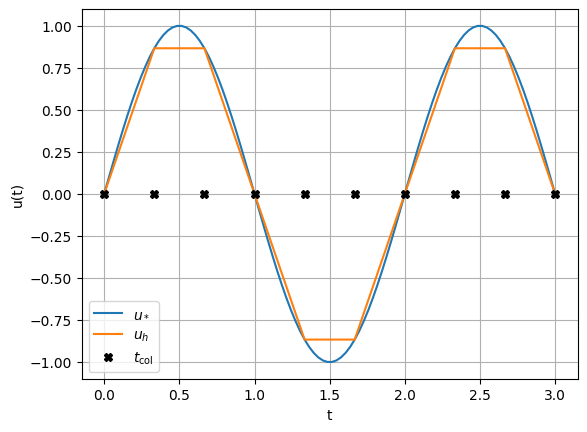

In [5]:
def train(params, loss_fn, optimizer=None, n_epochs=100, print_every=10):
    """
    Train parameters using the given optimizer and loss function.
    
    Args:
        params: pytree of parameters to optimize
        loss_fn: function(params) -> scalar loss
        optimizer: optax optimizer instance
        n_epochs: number of training epochs
        print_every: how often to print progress
    
    Returns:
        params: optimized parameters
        opt_state: final optimizer state
        history: list of loss values
    """
    if optimizer is None: optimizer = optax.lbfgs(learning_rate=0.1)
    # Initialize optimizer state
    opt_state = optimizer.init(params)

    # Define one train step
    @jax.jit
    def train_step(params, opt_state):
        loss_value, grads = jax.value_and_grad(loss_fn)(params)
        updates, opt_state = optimizer.update(grads, opt_state, params, value=loss_value, grad=grads, value_fn=loss_fn)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss_value, grads, updates

    # Training loop
    history = []
    for epoch in range(n_epochs):
        params, opt_state, loss_value, grads, updates = train_step(params, opt_state)
        history.append(loss_value)
        if epoch % print_every == 0:
            print(f"Epoch {epoch:7d}, Loss: {loss_value:.3e}")

    return params, opt_state, history


# Re-test with previous example, but now with train function
t0, t1, n_colloc = 0, 3, 10
def u(t):
    return np.sin(np.pi * t)

data = (t_colloc, u(t_colloc))

def machine(t_machine, coeff, t):
    phi = relu_hat_basis(t_machine, t)  # (n_colloc, len(t))
    return jnp.dot(coeff, phi)

def loss(params):
    res = data[1] - machine(t_colloc, params, data[0])
    return jnp.mean(res ** 2)
params = jnp.zeros(shape=(len(t_colloc)))
params, opt_state, history = train(params, loss)
t_plot = np.linspace(t0, t1, 100)
plot_results(t_plot, u(t_plot), machine(t_colloc, params, t_plot), [(t_colloc, 'Xk', r'$t_{\rm col}$')])


Même chose, mais avec des points de la machine différents de la collocation. Donc la perte est mantenant 
$${\mathcal L}(c) = \frac{1}{2m}\sum_{i=0}^m \left(u(t_i)-u_h(t_i)\right)^2.$$
Avec $m$ différent de $n$, de préférence plus grand. *Pourquoi ?*


Notre problème devient un véritable problème de moindres carrés. *D'ailleurs, peut-on calcluer la solutin à la main ? Que peut-on dire de l'erreur ? Est-il plus petite ou plus grande qu'avant ?*

On rencontre un problème typique de l'apprentissage : la valeur de la perte est difficile à interpréter. Ne pouvant pas s'attenre à ce qu'elle converge vers zéro, quand devrait-on s'arrêter ?

Epoch       0, Loss: 4.833e-01
Epoch      10, Loss: 7.346e-03
Epoch      20, Loss: 1.123e-03
Epoch      30, Loss: 9.783e-04
Epoch      40, Loss: 9.740e-04
Epoch      50, Loss: 9.739e-04
Epoch      60, Loss: 9.739e-04
Epoch      70, Loss: 9.739e-04
Epoch      80, Loss: 9.739e-04
Epoch      90, Loss: 9.739e-04


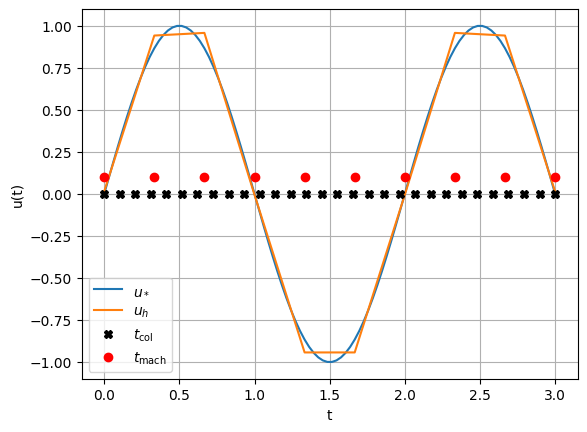

In [6]:
import optax

t0, t1, n_colloc, n_machine = 0, 3, 30, 10
t_colloc = np.linspace(t0, t1, n_colloc)
t_machine= np.linspace(t0, t1, n_machine)

def u(t):
    return np.sin(np.pi * t)

data = (t_colloc, u(t_colloc))

def loss(params):
    res = data[1] - machine(t_machine, params, data[0])
    return jnp.mean(res ** 2)
 
params = jnp.zeros(shape=(len(t_machine)))
params, opt_state, history = train(params, loss)

t_plot = np.linspace(t0, t1, 100)
pointlist = [(t_colloc, 'Xk', r'$t_{\rm col}$'), (t_machine, 'or', r'$t_{\rm mach}$')]
plot_results(t_plot, u(t_plot), machine(t_machine, params, t_plot), pointlist=pointlist)



Maintenant on essaie avec un vrai réseau de neurones : la première couche génère les fonctions de bases sur un maillage, dont les points sont aussi des paramètres. *Il s'agit d'uné méthode adaptative.*

Comme nous avons plusieurs paramètres, on utilise un dictionnaire. La base n'est plus une classe, juste une fonction.

* On peut être surpris de la bonne convergence. Cela dépend largement de l'initialisation.
* Est-ce que l'erreur est plus petite qu'avant ? Qu'est-ce qu'on peut dire ?

Epoch       0, Loss: 4.950e-01
Epoch      10, Loss: 7.669e-03
Epoch      20, Loss: 1.259e-03
Epoch      30, Loss: 7.047e-04
Epoch      40, Loss: 5.686e-04
Epoch      50, Loss: 5.338e-04
Epoch      60, Loss: 3.922e-04
Epoch      70, Loss: 2.638e-04
Epoch      80, Loss: 2.312e-04
Epoch      90, Loss: 2.125e-04


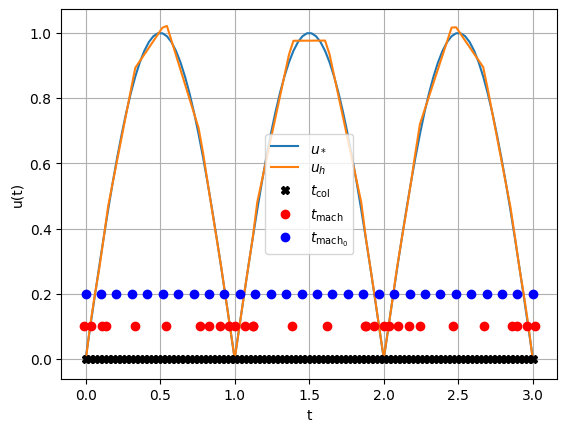

In [7]:
import optax

t0, t1, n_colloc, n_machine = 0, 3, 100, 30
t_colloc = np.linspace(t0, t1, n_colloc)

def u(t):
    return np.abs(np.sin(np.pi * t))

def model(params, t):
    phi = relu_hat_basis(params["t_machine"], t)   # (n_machine, n_points)
    return jnp.dot(params["coeffs"], phi)

def loss(params):
    res = model(params, t_colloc) - u(t_colloc)
    return jnp.mean(res**2)

params = {
    "coeffs": jnp.zeros(n_machine),
    "t_machine": jnp.linspace(0, 3, n_machine)     # trainable mesh!
}
t_machine_0 = params["t_machine"]

params, opt_state, history = train(params, loss)

t_machine = params["t_machine"]
coeffs = params["coeffs"]
t_plot = np.linspace(t0, t1, 100)
pointlist = [(t_colloc, 'Xk', r'$t_{\rm col}$'), (t_machine, 'or', r'$t_{\rm mach}$'), (t_machine_0, 'ob', r'$t_{\rm mach_0}$')]
plot_results(t_plot, u(t_plot), machine(t_machine, coeffs, t_plot), pointlist=pointlist)


Maintenant on va faire le même chose avec un maillage machine perturbé aléatoirement.

Epoch       0, Loss: 4.950e-01
Epoch      10, Loss: 1.179e-02
Epoch      20, Loss: 1.849e-03
Epoch      30, Loss: 1.120e-03
Epoch      40, Loss: 9.881e-04
Epoch      50, Loss: 9.320e-04
Epoch      60, Loss: 9.087e-04
Epoch      70, Loss: 9.041e-04
Epoch      80, Loss: 7.863e-04
Epoch      90, Loss: 7.217e-04


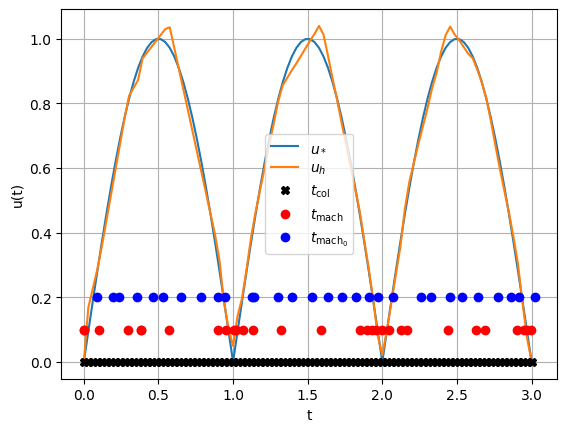

In [8]:
def random_mesh(t0, t1, n_colloc, p=0.5):
    import jax.random as random
    key = random.PRNGKey(0)
    t_uniform = jnp.linspace(t0, t1, n_colloc)
    h = (t1 - t0)/(n_colloc-1)
    noise = 0.9 * h * random.uniform(key, shape=(n_colloc,))
    t_random = t_uniform + noise
    t_random = jnp.sort(t_random)
    return t_random


t_random = random_mesh(t0, t1, n_machine)

params = {
    "coeffs": jnp.zeros(n_machine),
    "t_machine": t_random     # trainable mesh!
}

params, opt_state, history = train(params, loss)


t_machine = params["t_machine"]
coeffs = params["coeffs"]
t_plot = np.linspace(t0, t1, 100)
pointlist = [(t_colloc, 'Xk', r'$t_{\rm col}$'), (t_machine, 'or', r'$t_{\rm mach}$'), (t_random, 'ob', r'$t_{\rm mach_0}$')]
plot_results(t_plot, u(t_plot), machine(t_machine, coeffs, t_plot), pointlist=pointlist)



